introduction to machine learning:linear regression

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score    
from sklearn.datasets import fetch_openml


1.loading the data
real home sale records=no need to simulate anything

In [ ]:
housing=fetch_openml(name="house_prices", as_frame=True, parser="auto")

In [ ]:
type(housing)

sklearn.utils._bunch.Bunch

In [ ]:
df = housing.frame

In [ ]:
type(df)

pandas.DataFrame

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [ ]:
df=df[['LotArea', 'OverallQual', 'YearBuilt', 'TotRmsAbvGrd', 'SalePrice']]
df=df.rename(columns={'LotArea':'lot_area', 'OverallQual':'overall_quality', 'YearBuilt':'year_built', 'TotRmsAbvGrd':'total_rooms', 'SalePrice':'sale_price'})


In [ ]:
df['age'] = 2024 - df['year_built']
df=df.drop(columns=['year_built']).dropna()

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   lot_area         1460 non-null   int64
 1   overall_quality  1460 non-null   int64
 2   total_rooms      1460 non-null   int64
 3   sale_price       1460 non-null   int64
 4   age              1460 non-null   int64
dtypes: int64(5)
memory usage: 57.2 KB


2.can we predict price from size?

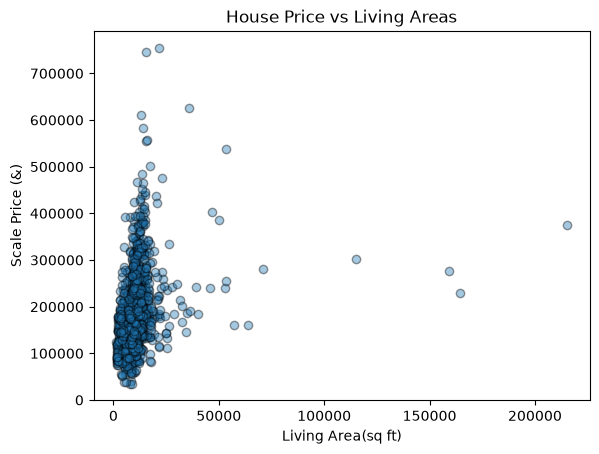

In [ ]:
plt.scatter(df['lot_area'], df['sale_price'], alpha=0.4, edgecolors="black")
plt.xlabel('Living Area(sq ft)')
plt.ylabel('Scale Price (&)')
plt.title('House Price vs Living Areas')
plt.show()

In [ ]:
x=df[['lot_area']]
y=df['sale_price']
model=LinearRegression()
model.fit(x, y)
print(f"Model Coefficients: {model.coef_}")
print(f"Model Intercept: {model.intercept_}")

Model Coefficients: [2.09997195]
Model Intercept: 158836.1518968766


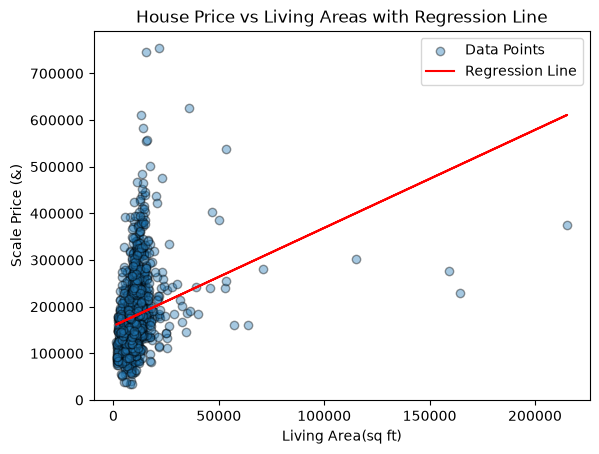

In [ ]:
plt.scatter(df['lot_area'], df['sale_price'], alpha=0.4, edgecolors="black",label='Data Points')
plt.plot(df['lot_area'], model.predict(x), color='red', label='Regression Line')
plt.xlabel('Living Area(sq ft)')
plt.ylabel('Scale Price (&)')
plt.title('House Price vs Living Areas with Regression Line')
plt.legend(loc='best')
plt.show()



4.residuals:how wrong is each prediction?

In [ ]:
df['predicted_price'] = model.predict(x)
df['residuals'] = df['sale_price'] - df['predicted_price']
df[['lot_area', 'sale_price', 'predicted_price', 'residuals']].head()

,lot_area,sale_price,predicted_price,residuals
0,8450,208500,176580.914889,31919.085111
1,9600,181500,178995.882633,2504.117367
2,11250,223500,182460.836354,41039.163646
3,9550,140000,178890.884036,-38890.884036
4,14260,250000,188781.751928,61218.248072


5.how good is the fit?

In [ ]:
print("R^2 Score:", r2_score(df['sale_price'], df['predicted_price']))


R^2 Score: 0.0696133153821119


In [ ]:
rmse=root_mean_squared_error(df['sale_price'], df['predicted_price'])
print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 76601.25405310982


6.can this line predict houses it hasnt seen?
a.splitting the data into training and testing set

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(df[['lot_area']], df['sale_price'], test_size=0.2, random_state=42)

b.training the model

In [ ]:
training_model=LinearRegression()
training_model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[1.91]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['lot_area']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.61e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


c.making prediction on unknown data point

In [ ]:
y_pred=training_model.predict(x_test)

d.checking how good is our model

In [ ]:
print(f"test data R^2 Score: {r2_score(y_test, y_pred)}")
print(f"test data Root Mean Squared Error: {root_mean_squared_error(y_test, y_pred)}")

test data R^2 Score: 0.06273946887816162
test data Root Mean Squared Error: 84788.52525445858


In [ ]:
df['predicted_price'] = model.predict(x)

In [ ]:
print("r^2 Score:", r2_score(df['sale_price'], df['predicted_price']))

r^2 Score: 0.0696133153821119


In [ ]:
rmse = np.sqrt(root_mean_squared_error(df['sale_price'], df['predicted_price']))
print("Root Mean Squared Error (RMSE):", rmse)

Root Mean Squared Error (RMSE): 276.7693155917213
